# Source Injector

The source injector can produce mock simulated data independent of the MEGAlib software.

Standard data simulation requires the users to install and use MEGAlib to convolve the source model with the detector effects to generate data. The source injector utilizes the response generated by intensive simulation, which contains the statistical detector effects. With the source injector, you can convolve response, source model, and orientation to gain the mock data quickly. 

The advantages of using the source injector include:

- No need to install and use MEGAlib
- Get the data much faster than the standard simulation pipeline
- The generated data are in the format that can be used for spectral fitting, localization, imaging, etc.

The disadvantages are:

- The data are binned based on the binning of the response, which means that you lost the unbinned event distribution as you will get from the MEGAlib pipeline.
- If the response is coarse, the data you generated might not be precise.

In [2]:
%%capture
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import astropy.units as u
from pathlib import Path
from astropy.coordinates import SkyCoord
from astromodels.functions.function import Function1D, FunctionMeta
from cosipy import SpacecraftFile, SourceInjector
from histpy import Histogram
from threeML import Powerlaw, Band
from cosipy.threeml.custom_functions import SpecFromDat
from cosipy.util import fetch_wasabi_file
import shutil
import os
import pandas as pd

%matplotlib inline

In [38]:
data_dir = Path("/Users/parshad/Software/cosipyFiles")  # Current directory by default. Modify if you want a different path

## Get the data
The data can be downloaded by running the cells below. Each respective cell also gives the wasabi file path and file size. 

In [39]:
%%capture
zipped_response_path = data_dir/"psr_gal_DC2.h5.zip"  # this is the galactic response
response_path = data_dir/"psr_gal_DC2.h5"

# # download the galactic point source response ~6.69 GB
# if not response_path.exists():

#     fetch_wasabi_file("COSI-SMEX/DC2/Responses/PointSourceReponse/psr_gal_continuum_DC2.h5.zip", zipped_response_path)
    
    # # unzip the response
    # shutil.unpack_archive(zipped_response_path)
    
    # # delete the zipped response to save space
    # os.remove(zipped_response_path)


In [40]:
%%capture
orientation_path = data_dir/"20280301_3_month_with_orbital_info.ori"

# # download orientation file ~684.38 MB
# if not orientation_path.exists():
#     fetch_wasabi_file("COSI-SMEX/DC2/Data/Orientation/20280301_3_month.ori", orientation_path)

## Inject a source response

### Method 2: Read the spectrum from a file

In this method, we're loading spectral data from a file (crab_spec.dat) and visualizing it:

In [32]:
# Load data from the text file, skipping the index column
dataFlux = np.genfromtxt("NGC_4151_ec200_COSI.dat",comments = "#",usecols = (2),skip_footer=1,skip_header=5)
dataEn = np.genfromtxt("NGC_4151_ec200_COSI.dat",comments = "#",usecols = (1),skip_footer=1,skip_header=5)

# dataFlux1 = np.genfromtxt("/Users/parshad/Software/AGN_Coronae/NGC_4151_ec1000_COSI.dat",comments = "#",usecols = (2),skip_footer=1,skip_header=5)
# dataEn1 = np.genfromtxt("/Users/parshad/Software/AGN_Coronae/NGC_4151_ec1000_COSI.dat",comments = "#",usecols = (1),skip_footer=1,skip_header=5)


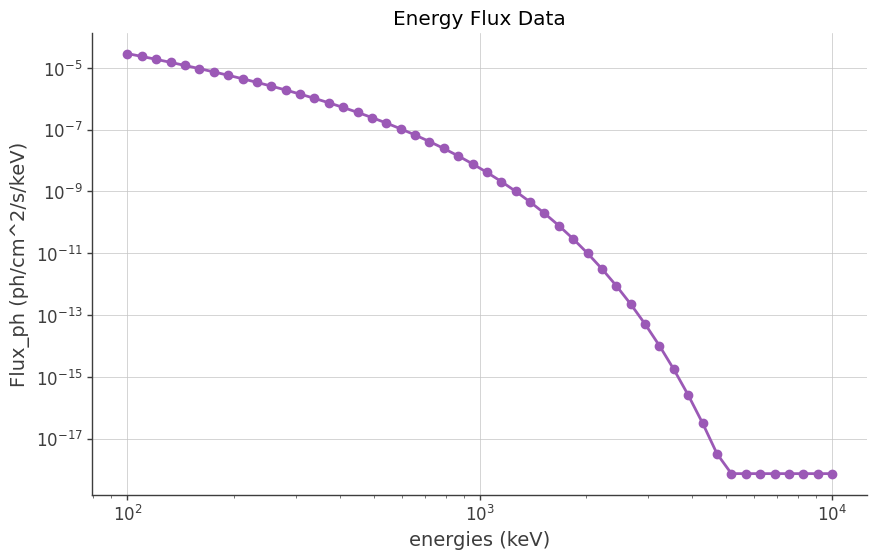

In [33]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dataEn, dataFlux, label="NGC4151 200keV Cutoff", marker="o", linestyle="-")
#plt.plot(dataEn1, dataFlux1, label="NGC4151 1000keV Cutoff", marker="o", linestyle="-")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("energies (keV)")
# plt.ylabel("Flux (keV cm^-2 s^-1)")
plt.ylabel("Flux_ph (ph/cm^2/s/keV)")
plt.title("Energy Flux Data")
plt.grid(True)
plt.show()

We use a custom class `SpecFromDat` to define a spectrum from data loaded from a CSV file `crab_spec.dat`


### SpecFromDat Class Explanation

The `SpecFromDat` class represents a spectrum loaded from a data file (`dat`, `txt`, `csv` etc.,). It provides methods to handle spectral data and evaluate the spectrum at specified energy values (`x`).

#### Class Description

- **Description**: 
  - A spectrum loaded from a data file (`dat`).

#### Parameters

- **K**:
  - **Description**: Normalization factor.
  - **Initial Value**: 1.0
  - **Is Normalization**: True
  - **Transformation**: log10
  - **Min**: 1e-30
  - **Max**: 1e3
  - **Delta**: 0.1
  - **Units**: `ph/cm2/s`

#### Properties

- **dat**:
  - **Description**: The data file from which the spectrum is loaded.
  - **Initial Value**: `test.dat`
  - **Defer**: True
  - **Units**:
    - **Energy**: `keV`.
    - **Flux**: `ph/cm2/s/keV`.
 
#### Functionality

- Loads flux (`dataFlux`) and energy (`dataEn`) from the specified data file (`self.dat.value`).
- Normalizes `dataFlux` using the widths of energy bins.
- Interpolates (`interp1d`) the normalized data to create a function (`fun`) for evaluating the spectrum.
- Evaluates the spectrum (`fun(x)`) at given energy values (`x`), scaled by the normalization factor (`K`).

In [41]:
# spectrum = SpecFromDat(K=1/18, dat="crab_spec.dat")

# spectrum = SpecFromDat(K=1, dat="/Users/parshad/Software/AGN_Coronae/NGC_4151_ec200_COSI.dat")
# spectrum = SpecFromDat(K=1, dat="/Users/parshad/Software/AGN_Coronae/NGC_4151_ec1000_COSI.dat")
# spectrum = SpecFromDat(K=0.00174, dat="/Users/parshad/Software/AGN_Coronae/NGC_4151_ec200_COSI.dat")
spectrum = SpecFromDat(K=0.00372, dat="/Users/parshad/Software/AGN_Coronae/NGC_4151_ec1000_COSI.dat")

### Read orientation file

In [42]:
# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.parse_from_file(orientation_path)

### Get the expected counts and save to a data file

In [43]:
# Define an injector by the response
injector = SourceInjector(response_path=response_path, response_frame = "galactic")

In [44]:
# Define the coordinate of the point source
# Need to change this eventually
source_coord = SkyCoord(l=155.0770628414967, b=75.0630654405054, frame="galactic", unit="deg")

CPU times: user 1.34 s, sys: 320 ms, total: 1.66 s
Wall time: 1.78 s


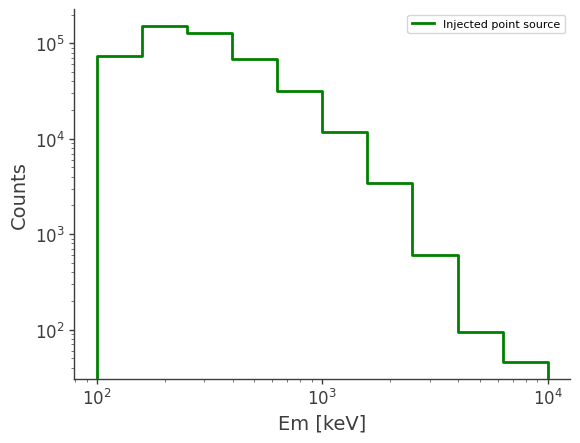

In [45]:
%%time

file_path = "/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec1000_COSI_sourceInj_correctFlux.hdf5"



# Check if the file exists and remove it if it does
if os.path.exists(file_path):
    os.remove(file_path)

# Get the data of the injected source
injector.inject_point_source(spectrum=spectrum, coordinate=source_coord, orientation=ori, source_name="NGC4151ec1000",
                             make_spectrum_plot=True, data_save_path=file_path, project_axes=None)

# Combine background and source data

In [46]:
# read the background file
bkg_hist = Histogram.open(data_dir/"bkg_binned_data.hdf5")

# read the injected source file
ngc_hist = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux.hdf5")

In [23]:
bkg_hist.axes.labels

array(['Time', 'Em', 'Phi', 'PsiChi'], dtype='<U6')

In [24]:
# We need to process the background and source data file to:
# 1. match the axes (including name and scale)
# 2. match the data unit

# collapse the time axis of the backgroun data
bkg_hist = bkg_hist.project(['Em', 'Phi', 'PsiChi'])

# reset the source data unit to the same one that the background data has
ngc_hist = ngc_hist.to(unit = bkg_hist.unit, update = False)

In [25]:
# Now you can add up the background and source dataall_daya = ngc_hist + bkg_hist
ngc_hist.write("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux_hist.hdf5")
ngc_bkg = ngc_hist + bkg_hist
ngc_bkg.write("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_bkg_hist.hdf5")

In [47]:
# read the background file
bkg_hist = Histogram.open(data_dir/"bkg_binned_data.hdf5")

# read the injected source file
ngc_hist = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec1000_COSI_sourceInj_correctFlux.hdf5")

In [48]:
bkg_hist.axes.labels

array(['Time', 'Em', 'Phi', 'PsiChi'], dtype='<U6')

In [49]:
ngc_hist.axes.labels

array(['Em', 'Phi', 'PsiChi'], dtype='<U6')

In [50]:
# We need to process the background and source data file to:
# 1. match the axes (including name and scale)
# 2. match the data unit

# collapse the time axis of the backgroun data
bkg_hist = bkg_hist.project(['Em', 'Phi', 'PsiChi'])
# ngc_hist = ngc_hist.project(['Em', 'Phi', 'PsiChi'])

# reset the source data unit to the same one that the background data has
ngc_hist = ngc_hist.to(unit = bkg_hist.unit, update = False)

In [51]:
bkg_hist.axes.labels

array(['Em', 'Phi', 'PsiChi'], dtype='<U6')

In [52]:
ngc_hist.axes.labels

array(['Em', 'Phi', 'PsiChi'], dtype='<U6')

In [53]:
# Now you can add up the background and source dataall_daya = ngc_hist + bkg_hist
ngc_hist.write("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec1000_COSI_sourceInj_correctFlux_hist.hdf5")
ngc_bkg = ngc_hist + bkg_hist
ngc_bkg.write("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec1000_bkg_hist.hdf5")

### (Optional) Compare simulated data with existing models

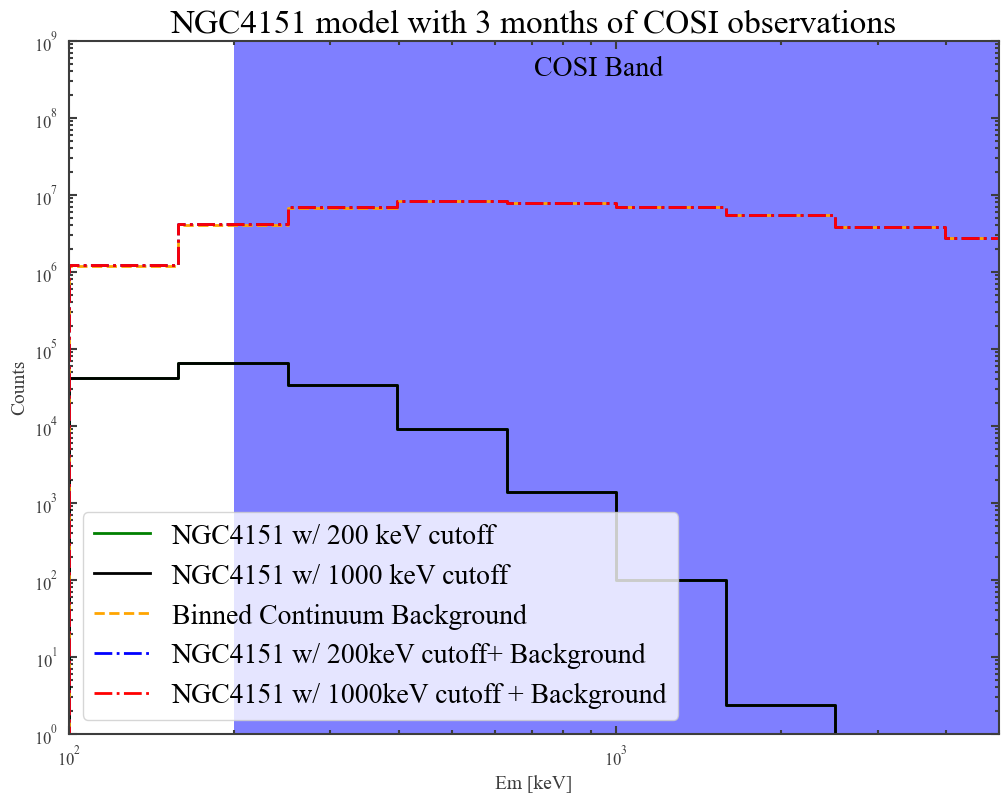

In [ ]:
# NGC4151ec200 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj.h5").project("Em")
# NGC4151ec1000 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec1000_COSI_sourceInj.h5").project("Em")
NGC4151ec200 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux.h5").project("Em")
NGC4151ec1000 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec1000_COSI_sourceInj_correctFlux.h5").project("Em")
# background = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/total_bg_3months_binned_for_continuum.hdf5").project("Em")
background = Histogram.open("/Users/parshad/Software/cosipyFiles/bkg_binned_data.hdf5").project("Em")
# print(NGC4151ec200.unit)

# background_pd = pd.read_hdf("/Users/parshad/Software/AGN_Coronae/SourceInj/total_bg_3months_binned_for_continuum.hdf5")
# print(background_pd)

plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5

fig, ax = plt.subplots(figsize=(12, 9))

NGC4151ec200.draw(ax, label="NGC4151 w/ 200 keV cutoff", color="green")
NGC4151ec1000.draw(ax, label="NGC4151 w/ 1000 keV cutoff", color="black")
# NGC4151ec200.draw(label="NGC4151 w/ 200 keV cutoff", color="green")


background.draw(
    ax, label="Binned Continuum Background", color="orange", linestyle="dashed"
)

# units = u.cm / u.cm / u.keV / u.s 
# background_untis = background.to()
NGC4151ec200_bkg = NGC4151ec200 + (background * NGC4151ec200.unit)
NGC4151ec1000_bkg = NGC4151ec1000 + (background * NGC4151ec1000.unit)
# NGC4151ec200_bkg = NGC4151ec200 + background

NGC4151ec200_bkg.draw(ax, label="NGC4151 w/ 200keV cutoff+ Background", linestyle='dashdot', color="blue")
NGC4151ec1000_bkg.draw(ax, label="NGC4151 w/ 1000keV cutoff + Background", linestyle='dashdot', color="red")

# NGC4151ec200_bkg.write(data_dir/"NGC4151_ec200_plusBkg.hdf5", overwrite=True)
# NGC4151ec1000_bkg.write(data_dir/"NGC4151_ec1000_plusBkg.hdf5", overwrite=True)
# print("Model", background.unit)
# print("Model", NGC4151ec200.unit)

ax.xaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', top='on', pad=8)
ax.xaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', right='on', pad=8)
ax.yaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=20,  loc='lower left')
ax.set_ylabel("Counts")
ax.set_xlim(1e2, 5e3)
ax.set_ylim(1e0, 1e9)
ax.axvspan(200, 5000, facecolor ='b', alpha = 0.5) 
ax.text(0.5, 0.95,'COSI Band', transform=ax.transAxes)
ax.set_title("NGC4151 model with 3 months of COSI observations")
plt.show()

In [9]:
# crab = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux.h5").project("Em")

# fig, ax = plt.subplots(figsize=(12, 9))

# crab.draw(ax, label="Crab Galactic", color="green")
# ax.set_xscale('log')
# ax.set_yscale('log')
# plt.show()


import h5py

# Path to your HDF5 file
file_path = "/Users/parshad/Software/cosipyFiles/crab_bkg_binned_data_galactic.hdf5"

# Open the file in read mode
with h5py.File(file_path, 'r') as h5_file:
    # List all groups and datasets in the file
    def explore(name, obj):
        print(f"{name}: {obj}")
    
    print("Contents of the HDF5 file (Crab from BG_estimation example):")
    h5_file.visititems(explore)  # Recursively explore the file

# with h5py.File(file_path, 'r') as h5_file:
#     # Access a specific dataset by its path
#     dataset_path = "hist/contents"  # Replace with the actual dataset path
#     data = h5_file[dataset_path][3]
#     print(f"Data from {dataset_path}:")
#     print(data)



Contents of the HDF5 file (Crab from BG_estimation example):
hist: <HDF5 group "/hist" (2 members)>
hist/axes: <HDF5 group "/hist/axes" (4 members)>
hist/axes/0: <HDF5 dataset "0": shape (2218,), type "<f8">
hist/axes/1: <HDF5 dataset "1": shape (11,), type "<f8">
hist/axes/2: <HDF5 dataset "2": shape (37,), type "<f8">
hist/axes/3: <HDF5 dataset "3": shape (769,), type "<i8">
hist/contents: <HDF5 group "/hist/contents" (4 members)>
hist/contents/coords: <HDF5 dataset "coords": shape (4, 167667047), type "<i8">
hist/contents/data: <HDF5 dataset "data": shape (167667047,), type "<f8">
hist/contents/fill_value: <HDF5 dataset "fill_value": shape (), type "<f8">
hist/contents/shape: <HDF5 dataset "shape": shape (4,), type "<i8">
